In [ ]:
### 1.3 자주 하는 실수

|실수|원인|해결|
|---|---|---|
|`df['name', 'test']` 사용|대괄호 한 쌍은 단일 열용|`df[['name', 'test']]`로 리스트 전달|
|`df.test`만 사용|열 이름에 공백·한글 있으면 실패|`df['test']` 형식 권장|
|`iterrows()` 안에서 값 수정|원본에 반영 안 됨|수정은 `df.loc[idx, '열이름'] = 값`|

### 1.4 자가 점검

- [ ] 시리즈와 데이터프레임의 차이를 한 문장으로 설명할 수 있는가?
- [ ] 'sum' 열의 값이 80 이상인 학생의 'name'만 추출하는 코드를 짤 수 있는가?

---

## 2. 데이터 전처리 (핵심 섹션)

> **왜 가장 중요한가?** 실제 데이터의 60~80%는 분석에 바로 쓸 수 없는 형태입니다. 누락치, 이상치, 형식 불일치, 중복 등을 정리하지 않으면 분석 결과 자체를 신뢰할 수 없습니다. 본 절은 **탐지 → 처리 → 검증** 3단계로 전처리 사고법을 익힙니다.

### 2.1 학습목표

- 데이터프레임의 열 이름·정렬·조건부 값 부여를 수행할 수 있다.
- **누락 데이터(NaN)를 탐지하고, 상황에 맞게 삭제 또는 대체할 수 있다.**
- 두 개 이상의 데이터프레임을 공통 키로 결합할 수 있다.

---

### 2.2 데이터 조작

#### 2.2.1 핵심 함수 정리

|작업|함수|핵심 매개변수|
|---|---|---|
|열 이름 변경|`df.rename()`|`columns={옛이름: 새이름}`|
|정렬|`df.sort_values()`|`by='기준열'`, `ascending=False`|
|조건부 값 부여|`np.where()`|조건, 참값, 거짓값|
|빈도수|`df['열'].value_counts()`|—|
|열 삭제|`df.drop()`|`columns=['열이름']`, `inplace=True`|

#### 2.2.2 실습 코드

```python
# [코드 11-13] 열 이름 변경
df = df.rename(columns={'test': 'exam'})

# [코드 11-14] 'sum' 열 기준 내림차순 정렬
sort_df = df.sort_values(by='sum', ascending=False)

# [코드 11-15] 조건에 따라 'grade' 열 생성 (다중 조건)
import numpy as np
df['grade'] = np.where(df['sum'] >= 90, 'A',
              np.where(df['sum'] >= 80, 'B', 'C'))

# [코드 11-16] 합격/불합격 분류
df['result'] = np.where(df['sum'] >= 80, 'pass', 'fail')

# [코드 11-17] 빈도수 확인
df['result'].value_counts()
# pass    3
# fail    1

# [코드 11-19] 열 삭제
df = df.drop(columns=['result'])
```

#### 2.2.3 자주 하는 실수

|실수|결과|해결|
|---|---|---|
|`df.rename({'test': 'exam'})`만 호출|원본 변경 안 됨|결과를 다시 할당하거나 `inplace=True`|
|`sort_values()`만 호출|원본 그대로|`df = df.sort_values(...)` 또는 `inplace=True`|
|`np.where`로 3단계 분기 시 괄호 누락|SyntaxError|중첩 `np.where` 안쪽 괄호 주의|

---

### 2.3 누락 데이터 처리 (★ 본 노트의 핵심)

#### 2.3.1 왜 누락 데이터가 생기는가?

- 설문 응답자가 일부 항목을 비워둠
- 센서 측정 실패
- 시스템 통합 과정의 매핑 누락
- 정상값이지만 표기 규칙이 다름 (예: '미상', '-', 빈 문자열)

판다스에서는 누락 데이터를 **`NaN` (Not a Number)** 으로 표현합니다. NumPy의 `np.nan`이 그 실체입니다.

#### 2.3.2 누락 데이터 의사결정 트리

> 누락치를 처음 만났을 때 항상 이 순서로 판단하세요.

```
Q1. 누락이 있는가?               → df.isna().sum()으로 확인
   │
   └─ 있다면
       │
       Q2. 분석에 꼭 필요한 열인가?
       │  ├─ 아니다 → drop(columns=...)으로 열 자체 삭제
       │  └─ 그렇다 → Q3
       │
       Q3. 누락 행이 전체의 5% 미만인가?
       │  ├─ 그렇다 → dropna()로 행 삭제 (subset 권장)
       │  └─ 아니다 → Q4
       │
       Q4. 어떤 값으로 채우는 것이 합리적인가?
          ├─ 범주형 → 'unknown', 'etc' 등 라벨로 fillna
          ├─ 수치형(정규분포) → 평균(mean)으로 fillna
          ├─ 수치형(왜곡 큼)  → 중앙값(median)으로 fillna
          └─ 시계열         → 직전값(ffill) 또는 직후값(bfill)
```

#### 2.3.3 실습 (1) — 누락 탐지

```python
# [코드 11-22] 누락이 포함된 데이터프레임 생성
import pandas as pd
import numpy as np

data = {
    'name':   ['김철수', '이영희', np.nan, '최지원', '정민호'],
    'gender': ['M', 'F', 'F', np.nan, 'M'],
    'score':  [85, np.nan, 78, 92, np.nan]
}
df = pd.DataFrame(data)
display(df)
```

실행 결과:

```
    name gender  score
0   김철수      M   85.0
1   이영희      F    NaN
2     NaN      F   78.0
3   최지원    NaN   92.0
4   정민호      M    NaN
```

```python
# [코드 11-23] 누락 여부 확인 (전체 표 반환)
df.isna()
# True/False로 채워진 같은 크기의 표

# 열별 누락 개수 (대규모 데이터에서 실용적)
df.isna().sum()
# name      1
# gender    1
# score     2

# 전체 누락 개수
df.isna().sum().sum()  # 4
```

#### 2.3.4 실습 (2) — 누락 행 삭제 (`dropna`)

```python
# [코드 11-25] 누락이 한 개라도 있는 행 모두 삭제
df1 = df.dropna()
# 결과: 0번 행만 남음 (다른 행은 모두 NaN을 한 개 이상 포함)

# [코드 11-26] 'name', 'score' 열만 분석할 경우
# → 'gender' 열의 NaN은 무시하고, name 또는 score가 NaN인 행만 삭제
df2 = df.dropna(subset=['name', 'score'])

# [코드 11-27] 원본에 반영하려면
df.dropna(inplace=True)
```

> **💡 `subset`이 핵심인 이유** 분석 목적과 무관한 열의 NaN까지 행 단위로 삭제하면 너무 많은 데이터가 사라집니다. **분석에 실제로 사용할 열만 `subset`에 명시**하는 습관을 들이세요.

#### 2.3.5 실습 (3) — 값으로 대체 (`fillna`)

```python
# [코드 11-28] 모든 NaN을 0으로 대체
df1 = df.fillna(0)

# [코드 11-29] 열마다 다른 값으로 대체 (딕셔너리)
df2 = df.fillna({
    'gender': 'etc',   # 범주형 → 'etc'
    'score':  0        # 수치형 → 0
})

# [코드 11-30] 평균으로 대체 (수치형 권장)
df3 = df.fillna({'score': df['score'].mean()})

# [코드 11-31] 원본 반영
df.fillna({'score': df['score'].mean()}, inplace=True)
```

#### 2.3.6 자주 하는 실수

|실수|결과|해결|
|---|---|---|
|`df == np.nan` 으로 비교|항상 False (NaN은 자기 자신과도 같지 않음)|`df.isna()` 사용|
|`dropna()` 후 원본 그대로|반환값을 안 받음|`df = df.dropna()` 또는 `inplace=True`|
|모든 NaN을 0으로 일괄 대체|평균·표준편차 왜곡|의사결정 트리에 따라 열별 분기|
|`fillna(df.mean())` 호출 시 모든 수치열 평균으로 채움|의도치 않게 다른 열까지 변경|딕셔너리로 열 지정|

#### 2.3.7 자가 점검

- [ ] `isna()`와 `isna().sum()`의 차이를 설명할 수 있는가?
- [ ] `dropna()`에서 `subset`을 쓰는 이유를 설명할 수 있는가?
- [ ] 'score' 열의 NaN을 평균으로, 'gender' 열의 NaN을 'etc'로 한 번에 대체하는 코드를 짤 수 있는가?

---

### 2.4 데이터프레임 결합 (`merge`)

#### 2.4.1 핵심 개념

서로 다른 두 데이터프레임을 **공통 열(key)** 을 기준으로 합칩니다. SQL의 JOIN과 같은 개념입니다.

#### 2.4.2 실습 코드

```python
# [코드 11-32, 11-33, 11-34] 두 DF를 'name' 기준으로 결합
df1 = pd.DataFrame({
    'name':   ['김철수', '이영희', '박민수'],
    'gender': ['M', 'F', 'M'],
    'age':    [21, 22, 20]
})
df2 = pd.DataFrame({
    'name':       ['김철수', '이영희', '박민수'],
    'department': ['컴퓨터공학', '경영학', '토목공학']
})

df3 = pd.merge(df1, df2, on='name')
display(df3)

# [코드 11-35, 11-36] 또 다른 키로 추가 결합
df4 = pd.DataFrame({
    'department':       ['컴퓨터공학', '경영학', '토목공학'],
    'head of department': ['이정수', '김영규', '최희재']
})
df5 = pd.merge(df3, df4, on='department')
```

#### 2.4.3 자주 하는 실수

- 공통 열 이름이 두 개 이상일 때 `on`을 명시하지 않으면 의도와 다르게 결합됩니다. **공통 열이 하나뿐이어도 `on=` 명시를 권장**합니다.
- 결합 키의 값이 한쪽에만 있는 경우(예: df1에는 있지만 df2에는 없는 학생)는 기본값 `how='inner'`로 사라집니다. 모두 보존하려면 `how='outer'`, 왼쪽 기준이면 `how='left'`를 사용합니다.

---

## 3. 판다스 함수 (요약)

### 3.1 통계 함수

```python
# [코드 11-37] 모든 수치형 열의 기초 통계량 한 번에
df.describe()
# count, mean, std, min, 25%, 50%, 75%, max

# 개별 함수
df['score'].mean()    # 평균
df['score'].median()  # 중앙값
df['score'].std()     # 표준편차
df['score'].max()     # 최댓값
df['score'].min()     # 최솟값
```

### 3.2 문자열 함수와 자료형 변환

|함수|용도|
|---|---|
|`str.replace()`|문자열 치환|
|`str.contains()`|포함 여부 (Boolean)|
|`str.split()`|분할|
|`str.strip()`|양 끝 공백 제거|
|`astype()`|자료형 변환|

```python
# [코드 11-39 계열] 단위가 섞인 문자열에서 정수만 추출
df['temp_value'] = df['temp'].str.replace('°C', '').astype(int)
df['height_value'] = df['height'].str.replace('m', '').astype(int)
```

---

## 4. 파일 데이터 이용

### 4.1 학습목표

- CSV 파일을 읽고 저장할 수 있다.
- 한글 인코딩 문제(EUC-KR)를 진단하고 해결할 수 있다.
- 큰 데이터프레임을 `head`, `tail`, `shape`로 빠르게 파악할 수 있다.

### 4.2 CSV 파일 입출력

```python
# [코드 11-40] CSV 파일 읽기
df = pd.read_csv('precipitation.csv')

# [코드 11-43] CSV 파일 저장
df.to_csv('precipitation_out.csv')

# [코드 11-44] 행 인덱스 번호 제외하고 저장 (실무 표준)
df.to_csv('precipitation_out.csv', index=False)
```

### 4.3 인코딩 문제 진단 — 흔한 함정

```python
# [코드 11-45] 그대로 실행 시 오류 발생 가능
df = pd.read_csv('학급당학생수.csv')
# UnicodeDecodeError: 'utf-8' codec can't decode byte ...
```

**원인**: 한국 공공기관 CSV 파일은 EUC-KR 인코딩인 경우가 많습니다.

**해결**:

```python
# [코드 11-46] 인코딩 옵션 추가
df = pd.read_csv('학급당학생수.csv', encoding='EUC-KR')
```

> **💡 디버깅 체크리스트** (인코딩 오류 발생 시)
>
> 1. `encoding='EUC-KR'` 추가 → 대부분 해결
> 2. 그래도 실패 시 `encoding='cp949'` 시도
> 3. 그래도 실패 시 `encoding='utf-8-sig'` (BOM 포함) 시도

### 4.4 데이터프레임 빠르게 파악하기

```python
# [코드 11-47] 앞/뒤 일부만 보기
df.head()      # 처음 5행
df.head(10)    # 처음 10행
df.tail()      # 마지막 5행

# [코드 11-48] 크기 확인
df.shape       # (행 수, 열 수) 튜플 반환
# 예: (14, 4)는 14행 4열

# 추가 진단 함수 (실무 권장)
df.info()        # 열 이름, 자료형, 누락치 개수 한 번에
df.columns       # 열 이름 목록
df.dtypes        # 각 열의 자료형
```

### 4.5 그래프에 한글 표시하기

```python
# [코드 11-49, 11-50] 한글 폰트 설치 (Colab 환경)
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)

# [코드 11-51] 사용 예시
import matplotlib.pyplot as plt

plt.plot(df['연도'], df['서울'])
plt.xlabel('연도', fontproperties=font10)
plt.ylabel('학급당 학생수', fontproperties=font10)
plt.title('서울 학급당 학생수 추이', fontproperties=font10)
plt.show()
```

---

## 5. 플러스 예제 — 자동차 배기량과 CO2 배출량의 상관관계

### 5.1 실습 시나리오

> **데이터**: 한국에너지공단 자동차 표시연비 정보 (`car20240731.csv`, 공공데이터포털 https://www.data.go.kr) **목표**: 휘발유·경유 차량 각각에 대해 배기량과 CO2 배출량의 상관관계를 분석. **이 절에서 강조하는 것**: 본 강좌의 핵심인 **데이터 전처리**가 실제 분석 흐름에서 어떻게 적용되는가.

### 5.2 단계별 실습

#### Step 1. 데이터 불러오기

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('car20240731.csv', encoding='EUC-KR')
print(df.shape)
df.head()
```

#### Step 2. 기초 진단

```python
df.info()
df[['배기량', '고속도로연비', 'CO2배출량']].describe()
```

> **확인 포인트**: `min` 값이 `0`인 열이 있는지 확인합니다. 본 데이터에서는 '배기량'과 '고속도로연비'에 0인 행이 존재합니다 — 이는 물리적으로 불가능한 값이므로 **이상치(혹은 누락치를 0으로 기록한 케이스)** 입니다.

#### Step 3. 이상치 제거 (전처리의 핵심)

```python
# 원본 행 수 기록
print('전처리 전:', df.shape)

# 배기량이 0인 행 삭제
df = df[df['배기량'] > 0]

print('전처리 후:', df.shape)
df[['배기량', 'CO2배출량']].describe()  # 통계량이 변했음을 확인
```

#### Step 4. 연료별 분리

```python
df1 = df[df['연료'] == '휘발유']
df2 = df[df['연료'] == '경유']
```

#### Step 5. 시각화 (산점도)

```python
plt.scatter(df1['배기량'], df1['CO2배출량'], alpha=0.5, label='Gasoline')
plt.scatter(df2['배기량'], df2['CO2배출량'], alpha=0.5, label='Diesel')
plt.xlabel('Displacement (cc)')
plt.ylabel('CO2 (g/km)')
plt.legend()
plt.show()
```

#### Step 6. 상관계수 분석

```python
r1 = df1['배기량'].corr(df1['CO2배출량'])
r2 = df2['배기량'].corr(df2['CO2배출량'])

print(f'휘발유 차량 상관계수: {r1:.3f}')
print(f'경유  차량 상관계수: {r2:.3f}')
```

### 5.3 결과 해석

- 두 연료 모두 **양의 상관관계** (배기량이 클수록 CO2 배출량 증가).
- 일반적으로 **휘발유 차량의 상관관계가 경유 차량보다 높게** 나타납니다 (원본 강의자료 슬라이드 126 참고).
- **만약 Step 3의 이상치 제거를 건너뛰었다면** 0 값들이 평균과 분산을 왜곡시켜 상관계수 자체가 다르게 계산됩니다 — 이것이 데이터 전처리가 결과의 신뢰성을 결정짓는 이유입니다.

---

## 부록 A. 종합 체크리스트 — 데이터 전처리 워크플로우

새 데이터셋을 받았을 때 항상 다음 순서로 점검합니다.

```
1. 불러오기
   □ 인코딩 확인 (UTF-8 / EUC-KR / cp949)
   □ df.shape — 크기는 예상 범위인가?

2. 구조 파악
   □ df.head() — 첫 5행 확인
   □ df.info() — 자료형과 누락치 개수
   □ df.describe() — 수치형 열의 min/max에 이상치 신호가 있는가?

3. 누락치 처리
   □ df.isna().sum() — 어느 열에 몇 개?
   □ 의사결정 트리 적용 (열 삭제 / 행 삭제 / 값 대체)

4. 이상치 처리
   □ 물리적으로 불가능한 값(예: 배기량 0)
   □ 도메인 지식으로 합리성 검증

5. 자료형 정리
   □ 숫자가 문자열로 들어와 있는가? → astype(int/float)
   □ 단위 문자가 섞여 있는가? → str.replace로 제거

6. 검증
   □ 전처리 전후의 통계량 비교
   □ 행 수 변화량 기록
```

---

## 부록 B. 자주 쓰는 명령 한눈에 보기

### 데이터 진단

|명령|용도|
|---|---|
|`df.head()` / `df.tail()`|일부 행 미리보기|
|`df.shape`|(행 수, 열 수)|
|`df.info()`|자료형 + 누락치|
|`df.describe()`|기초 통계량|
|`df.isna().sum()`|열별 누락치 개수|

### 누락치 처리

|명령|용도|
|---|---|
|`df.dropna()`|누락 행 삭제|
|`df.dropna(subset=[...])`|특정 열만 기준|
|`df.fillna(값)`|일괄 대체|
|`df.fillna({'열': 값, ...})`|열별 대체|
|`df.fillna(df.mean())`|평균 대체 (주의: 모든 수치열)|

### 데이터 조작

|명령|용도|
|---|---|
|`df.rename(columns={...})`|열 이름 변경|
|`df.sort_values(by='열')`|정렬|
|`df.drop(columns=[...])`|열 삭제|
|`pd.merge(df1, df2, on='키')`|결합|
|`np.where(조건, 참값, 거짓값)`|조건부 값 부여|

### 파일 입출력

|명령|용도|
|---|---|
|`pd.read_csv('파일')`|CSV 읽기|
|`pd.read_csv('파일', encoding='EUC-KR')`|한국 공공데이터|
|`df.to_csv('파일', index=False)`|CSV 저장 (인덱스 제외)|

---

## 부록 C. 추가 실습 과제 (자율)

|#|과제|사용 함수|난이도|
|---|---|---|---|
|1|5명 학생의 점수 데이터프레임을 만들고 평균 80점 이상인 학생만 추출|`DataFrame`, 조건 인덱싱|★|
|2|NaN이 포함된 학생 데이터에서 'name'이 누락된 행만 삭제|`dropna(subset=)`|★★|
|3|점수 열의 NaN을 그 열의 중앙값으로 대체|`fillna`, `median`|★★|
|4|학생 정보(df1)와 학과 정보(df2)를 'name' 키로 결합|`merge`|★★|
|5|5.2의 자동차 데이터에서 **고속도로연비 기준 상위 10대**의 평균 CO2 배출량 계산|`sort_values`, `head`, `mean`|★★★|

---


In [2]:
# [코드 11-1] 데이터프레임 생성 (딕셔너리 방식)
import pandas as pd

data = {
    'name': ['김철수', '이영희', '박민수', '최지원'],
    'test':    [85, 92, 78, 88],
    'assign1': [90, 85, 80, 95],
    'assign2': [88, 90, 75, 92]
}
df = pd.DataFrame(data)
display(df)  # 또는 print(df)

,name,test,assign1,assign2
0,김철수,85,90,88
1,이영희,92,85,90
2,박민수,78,80,75
3,최지원,88,95,92


In [3]:
df

,name,test,assign1,assign2
0,김철수,85,90,88
1,이영희,92,85,90
2,박민수,78,80,75
3,최지원,88,95,92


In [4]:
# [코드 11-6, 11-7] 열 추출
df['name']                # 한 개 열 → Series 반환
df[['name', 'test']]      # 두 개 이상 열 → DataFrame 반환

,name,test
0,김철수,85
1,이영희,92
2,박민수,78
3,최지원,88


In [5]:
# [코드 11-9] 행 순회
for idx, row in df.iterrows():
    print(idx, row['name'], row['test'])

# [코드 11-10] 열 간 연산
df['sum'] = df['test'] + df['assign1'] + df['assign2']


0 김철수 85
1 이영희 92
2 박민수 78
3 최지원 88


In [10]:
# [코드 11-11] 조건에 맞는 행 추출
df[df['sum'] >= 80]

,name,test,assign1,assign2,sum
0,김철수,85,90,88,263
1,이영희,92,85,90,267
2,박민수,78,80,75,233
3,최지원,88,95,92,275


In [11]:
df = df.rename(columns={'test': 'exam'})

In [12]:
df

,name,exam,assign1,assign2,sum
0,김철수,85,90,88,263
1,이영희,92,85,90,267
2,박민수,78,80,75,233
3,최지원,88,95,92,275


In [13]:
sort_df = df.sort_values(by='sum', ascending=False)

In [14]:
sort_df

,name,exam,assign1,assign2,sum
3,최지원,88,95,92,275
1,이영희,92,85,90,267
0,김철수,85,90,88,263
2,박민수,78,80,75,233


In [25]:
import numpy as np
df['grade'] = np.where(df['sum'] >= 260, 'A',
              np.where(df['sum'] >= 230, 'B', 'C'))

In [26]:
df

,name,exam,assign1,assign2,sum,grade,result
0,김철수,85,90,88,263,A,pass
1,이영희,92,85,90,267,A,pass
2,박민수,78,80,75,233,B,fail
3,최지원,88,95,92,275,A,pass


In [27]:
df['result'] = np.where(df['sum'] >= 260, 'pass', 'fail')

In [28]:
df

,name,exam,assign1,assign2,sum,grade,result
0,김철수,85,90,88,263,A,pass
1,이영희,92,85,90,267,A,pass
2,박민수,78,80,75,233,B,fail
3,최지원,88,95,92,275,A,pass


In [29]:
df['grade'].value_counts()

,count
grade,
A,3
B,1


In [31]:
df.to_csv('exam_out.csv')

In [48]:
import pandas as pd
import numpy as np

data = {
    'name':   ['김철수', '이영희', np.nan, '최지원', '정민호'],
    'gender': ['M', 'F', 'F', np.nan, 'M'],
    'score':  [85, np.nan, 78, 92, np.nan]
}
df1 = pd.DataFrame(data)
display(df1)

,name,gender,score
0,김철수,M,85.0
1,이영희,F,NaN
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,NaN


In [35]:
df1.isna().sum()

,0
name,1
gender,1
score,2


In [36]:
df2 = df1.dropna()

In [37]:
df2

,name,gender,score
0,김철수,M,85.0


In [38]:
df2 = df1.dropna(subset=['name', 'score'])

In [39]:
df2

,name,gender,score
0,김철수,M,85.0
3,최지원,NaN,92.0


In [40]:
df1.dropna(inplace=True)

In [41]:
df1

,name,gender,score
0,김철수,M,85.0


In [43]:
df2 = df1.fillna(0)

In [44]:
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,0,F,78.0
3,최지원,0,92.0
4,정민호,M,0.0


In [46]:
df2 = df1.fillna({
    'gender': 'etc',   # 범주형 → 'etc'
    'score':  0        # 수치형 → 0
})

In [47]:
df2

,name,gender,score
0,김철수,M,85.0
1,이영희,F,0.0
2,NaN,F,78.0
3,최지원,etc,92.0
4,정민호,M,0.0


In [52]:
df3 = df1.fillna({'score': df1['score'].mean()})

In [53]:
df3

,name,gender,score
0,김철수,M,85.0
1,이영희,F,85.0
2,NaN,F,78.0
3,최지원,NaN,92.0
4,정민호,M,85.0


In [54]:
df1 = pd.DataFrame({
    'name':   ['김철수', '이영희', '박민수'],
    'gender': ['M', 'F', 'M'],
    'age':    [21, 22, 20]
})
df2 = pd.DataFrame({
    'name':       ['김철수', '이영희', '박민수'],
    'department': ['컴퓨터공학', '경영학', '토목공학']
})


In [55]:
df1

,name,gender,age
0,김철수,M,21
1,이영희,F,22
2,박민수,M,20


In [56]:
df2

,name,department
0,김철수,컴퓨터공학
1,이영희,경영학
2,박민수,토목공학


In [58]:
df3 = pd.merge(df1, df2, on='name')
display(df3)

,name,gender,age,department
0,김철수,M,21,컴퓨터공학
1,이영희,F,22,경영학
2,박민수,M,20,토목공학


In [59]:
df4 = pd.DataFrame({
    'department':       ['컴퓨터공학', '경영학', '토목공학'],
    'head of department': ['이정수', '김영규', '최희재']
})

In [60]:
df4

,department,head of department
0,컴퓨터공학,이정수
1,경영학,김영규
2,토목공학,최희재


In [61]:
df5 = pd.merge(df3, df4, on='department')

In [62]:
df5

,name,gender,age,department,head of department
0,김철수,M,21,컴퓨터공학,이정수
1,이영희,F,22,경영학,김영규
2,박민수,M,20,토목공학,최희재


In [63]:
df = pd.read_csv('precipitation.csv')

In [64]:
df

,year,spring,summer,autumn,winter
0,2017,124.9,612.7,177.9,75.2
1,2018,383.5,620.6,351.3,68.7
2,2019,175.0,508.2,440.8,168.8
3,2020,173.7,1037.6,270.4,47.8
4,2021,330.5,612.8,256.4,13.3


In [68]:
df = pd.read_csv('학급당학생수.csv', encoding='EUC-KR')

FileNotFoundError: [Errno 2] No such file or directory: '학급당학생수.csv'

In [69]:
!apt-get update -qq
!apt-get install fonts-nanum -qq
!fc-cache -fv

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118212 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no

In [73]:
import matplotlib.font_manager as fm
font10 = fm.FontProperties(
    fname='/usr/share/fonts/truetype/nanum/NanumGothic.ttf',
    size=10
)


In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('car20240731.csv')
print(df.shape)
df.head()

(3498, 13)


,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
1,볼보,볼보 XC60T8 AWD,전기+휘발유,자동,PHEV,승용차,16.6,17.1,33.0,61.0,1969.0,PHEV,2024
2,벤츠,Mercedes-Benz GLC 220 d 4MATIC,경유,자동,하이브리드,승용차,13.8,15.5,130.0,NaN,1993.0,2등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
4,랜드로버,더 뉴 레인지로버 P550e SWB,전기+휘발유,자동,PHEV,승용차,11.5,13.1,35.0,80.0,2996.0,PHEV,2024


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3498 entries, 0 to 3497
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   업체명           3498 non-null   object 
 1   모델명           3498 non-null   object 
 2   연료            3498 non-null   object 
 3   변속형식          3498 non-null   object 
 4   차량형식          3498 non-null   object 
 5   자동차 종류        3498 non-null   object 
 6   도심주행연비        3497 non-null   float64
 7   고속도로연비        3497 non-null   float64
 8   CO2배출량(g_km)  3186 non-null   float64
 9   1회충전주행거리(km)  403 non-null    float64
 10  배기량           3187 non-null   float64
 11  등급            3498 non-null   object 
 12  출시연도          3498 non-null   int64  
dtypes: float64(5), int64(1), object(7)
memory usage: 355.4+ KB


In [86]:
df[['배기량', '고속도로연비', 'CO2배출량(g_km)']].describe()

,배기량,고속도로연비,CO2배출량(g_km)
count,3187.000000,3497.000000,3186.000000
mean,2557.875118,11.752617,168.908035
std,965.196309,4.508477,48.694492
min,0.000000,0.000000,14.000000
25%,1995.000000,9.800000,137.000000
50%,2199.000000,11.800000,167.000000
75%,2997.000000,14.100000,199.000000
max,6749.000000,92.600000,354.000000


In [87]:
df1 = df[df['연료'] == '휘발유']
df2 = df[df['연료'] == '경유']

In [88]:
df1

,업체명,모델명,연료,변속형식,차량형식,자동차 종류,도심주행연비,고속도로연비,CO2배출량(g_km),1회충전주행거리(km),배기량,등급,출시연도
0,볼보,볼보 V60CCB5 AWD,휘발유,자동,하이브리드,승용차,8.7,11.9,175.0,NaN,1969.0,4등급,2024
3,벤츠,Mercedes-Benz E 450 4MATIC,휘발유,자동,하이브리드,승용차,9.0,13.1,162.0,NaN,2998.0,4등급,2024
5,볼보,볼보 XC60B6 AWD,휘발유,자동,하이브리드,승용차,8.8,11.5,174.0,NaN,1969.0,4등급,2024
6,볼보,볼보 S60B5,휘발유,자동,하이브리드,승용차,10.5,14.3,143.0,NaN,1969.0,3등급,2024
7,벤츠,Mercedes-Maybach S 580,휘발유,자동,하이브리드,승용차,7.0,10.1,214.0,NaN,3982.0,5등급,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3486,GM,캐딜락 ATS-V,휘발유,자동,내연기관,승용차,7.0,10.2,221.0,NaN,3564.0,5등급,2016
3492,크라이슬러,짚 레니게이드 2.4,휘발유,자동,내연기관,승용차,8.9,11.9,171.0,NaN,2360.0,4등급,2015
3494,현대,아슬란 3.0GDI,휘발유,자동,내연기관,승용차,8.1,11.8,188.0,NaN,2999.0,4등급,2014
3495,현대,아슬란 3.3GDI,휘발유,자동,내연기관,승용차,8.1,11.9,188.0,NaN,3342.0,4등급,2014


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48176 (\N{HANGUL SYLLABLE BAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47049 (\N{HANGUL SYLLABLE RYANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


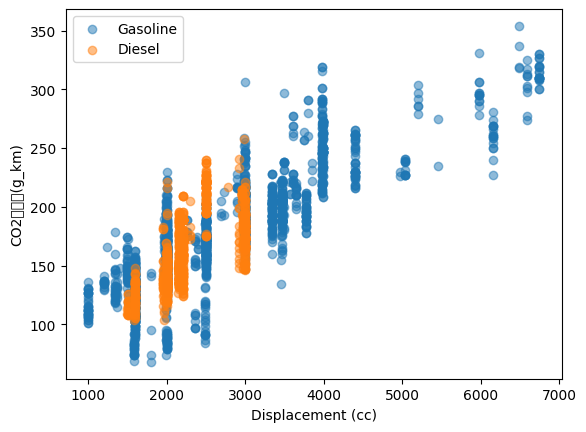

In [91]:
plt.scatter(df1['배기량'], df1['CO2배출량(g_km)'], alpha=0.5, label='Gasoline')
plt.scatter(df2['배기량'], df2['CO2배출량(g_km)'], alpha=0.5, label='Diesel')
plt.xlabel('Displacement (cc)')
plt.ylabel('CO2배출량(g_km)')
plt.legend()
plt.show()

In [92]:
r1 = df1['배기량'].corr(df1['CO2배출량(g_km)'])
r2 = df2['배기량'].corr(df2['CO2배출량(g_km)'])

print(f'휘발유 차량 상관계수: {r1:.3f}')
print(f'경유  차량 상관계수: {r2:.3f}')

휘발유 차량 상관계수: 0.856
경유  차량 상관계수: 0.656
